# 🫀 Framingham Heart Study — Data Cleaning Notebook

> **Dataset:** Framingham Heart Study (Kaggle)  
> **Goal:** Clean raw data → prepare it for EDA and supervised learning (CHD risk prediction)  
> **Author:** *(your name)*  
> **Date:** *(date)*

---

## 📋 Table of Contents
1. [Import Libraries](#1-import-libraries)
2. [Load Raw Data](#2-load-raw-data)
3. [Initial Inspection](#3-initial-inspection)
4. [Rename Columns](#4-rename-columns)
5. [Decode Binary & Categorical Columns](#5-decode-binary--categorical-columns)
6. [Handle Missing Values](#6-handle-missing-values)
7. [Data Type Validation](#7-data-type-validation)
8. [Outlier Check](#8-outlier-check)
9. [Final Cleaned Dataset](#9-final-cleaned-dataset)
10. [Export](#10-export)

---

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

# Plot style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'axes.titlesize': 13})

print('✅ Libraries loaded successfully')

✅ Libraries loaded successfully


## 2. Load Raw Data

In [ ]:
# ── Load the raw CSV ─────────────────────────────────────────────────────────

RAW_PATH = '../Data/0_raw_data/framingham.csv'
CLEANED_PATH = '../Data/1_cleaned_data/framingham_cleaned.csv'

df_raw = pd.read_csv(RAW_PATH)

# Keep a pristine copy — never mutate the original
df = df_raw.copy()

print(f'Rows : {df.shape[0]:,}')
print(f'Cols : {df.shape[1]}')


Rows : 4,240
Cols : 16


,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.00,0,0.00,0.00,0,0,0,195.00,106.00,70.00,26.97,80.00,77.00,0
1,0,46,2.00,0,0.00,0.00,0,0,0,250.00,121.00,81.00,28.73,95.00,76.00,0
2,1,48,1.00,1,20.00,0.00,0,0,0,245.00,127.50,80.00,25.34,75.00,70.00,0
3,0,61,3.00,1,30.00,0.00,0,1,0,225.00,150.00,95.00,28.58,65.00,103.00,1
4,0,46,3.00,1,23.00,0.00,0,0,0,285.00,130.00,84.00,23.10,85.00,85.00,0


In [ ]:
## 3. Initial Inspection

In [9]:
# ── Schema & dtypes ──────────────────────────────────────────────────────────
print('=== dtypes & null counts ===')
info = pd.DataFrame({
    'dtype'     : df.dtypes,
    'non_null'  : df.notnull().sum(),
    'null_count': df.isnull().sum(),
    'null_%'    : (df.isnull().sum() / len(df) * 100).round(2)
})
display(info)

=== dtypes & null counts ===


,dtype,non_null,null_count,null_%
male,int64,4240,0,0.00
age,int64,4240,0,0.00
education,float64,4135,105,2.48
currentSmoker,int64,4240,0,0.00
cigsPerDay,float64,4211,29,0.68
BPMeds,float64,4187,53,1.25
prevalentStroke,int64,4240,0,0.00
prevalentHyp,int64,4240,0,0.00
diabetes,int64,4240,0,0.00
totChol,float64,4190,50,1.18


In [10]:
# ── Descriptive statistics ───────────────────────────────────────────────────
df.describe(include='all').T

,count,mean,std,min,25%,50%,75%,max
male,4240.00,0.43,0.50,0.00,0.00,0.00,1.00,1.00
age,4240.00,49.58,8.57,32.00,42.00,49.00,56.00,70.00
education,4135.00,1.98,1.02,1.00,1.00,2.00,3.00,4.00
currentSmoker,4240.00,0.49,0.50,0.00,0.00,0.00,1.00,1.00
cigsPerDay,4211.00,9.01,11.92,0.00,0.00,0.00,20.00,70.00
BPMeds,4187.00,0.03,0.17,0.00,0.00,0.00,0.00,1.00
prevalentStroke,4240.00,0.01,0.08,0.00,0.00,0.00,0.00,1.00
prevalentHyp,4240.00,0.31,0.46,0.00,0.00,0.00,1.00,1.00
diabetes,4240.00,0.03,0.16,0.00,0.00,0.00,0.00,1.00
totChol,4190.00,236.70,44.59,107.00,206.00,234.00,263.00,696.00


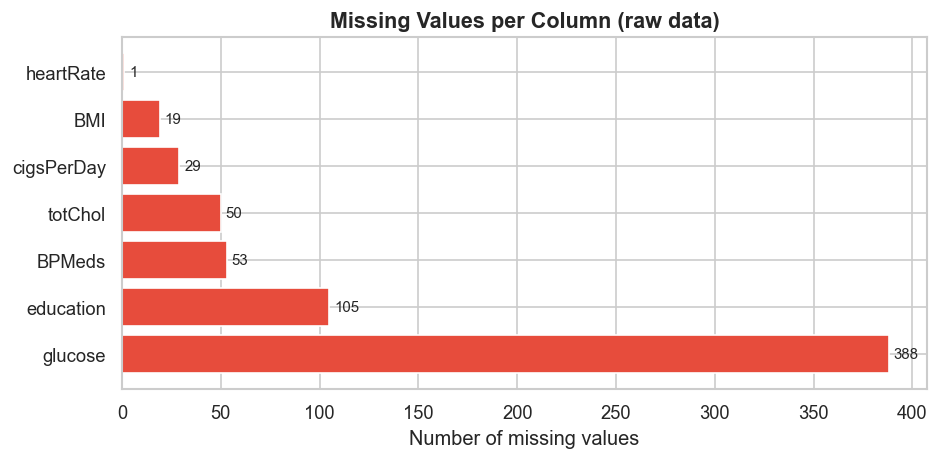


Total missing cells : 645
Total cells         : 67840
Missing %           : 0.95%


In [11]:
# ── Visualise missing values ─────────────────────────────────────────────────
null_counts = df.isnull().sum()
null_counts = null_counts[null_counts > 0].sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(null_counts.index, null_counts.values, color='#E74C3C', edgecolor='white')
ax.bar_label(bars, padding=3, fontsize=9)
ax.set_title('Missing Values per Column (raw data)', fontweight='bold')
ax.set_xlabel('Number of missing values')
plt.tight_layout()
plt.show()

print(f'\nTotal missing cells : {df.isnull().sum().sum()}')
print(f'Total cells         : {df.size}')
print(f'Missing %           : {df.isnull().sum().sum() / df.size * 100:.2f}%')

In [12]:
## 4. Rename Columns
   
# Original names are terse and ambiguous. We replace them with self-documenting snake_case names.

In [13]:
# ── Column rename map ────────────────────────────────────────────────────────
RENAME_MAP = {
    'male'           : 'gender',              # binary → will be decoded below
    'age'            : 'age',
    'education'      : 'education_level',     # 1-4 ordinal → will be labelled below
    'currentSmoker'  : 'is_smoker',
    'cigsPerDay'     : 'cigarettes_per_day',
    'BPMeds'         : 'on_bp_medication',
    'prevalentStroke': 'had_stroke',
    'prevalentHyp'   : 'has_hypertension',
    'diabetes'       : 'has_diabetes',
    'totChol'        : 'total_cholesterol',
    'sysBP'          : 'systolic_bp',
    'diaBP'          : 'diastolic_bp',
    'BMI'            : 'bmi',
    'heartRate'      : 'heart_rate',
    'glucose'        : 'glucose_level',
    'TenYearCHD'     : 'chd_risk_10yr',       # target variable
}

df = df.rename(columns=RENAME_MAP)

print('Columns after rename:')
print(df.columns.tolist())

Columns after rename:
['gender', 'age', 'education_level', 'is_smoker', 'cigarettes_per_day', 'on_bp_medication', 'had_stroke', 'has_hypertension', 'has_diabetes', 'total_cholesterol', 'systolic_bp', 'diastolic_bp', 'bmi', 'heart_rate', 'glucose_level', 'chd_risk_10yr']


In [ ]:
## 5. Decode Binary & Categorical Columns

## `0 / 1` binary flags → `'No' / 'Yes'` (human-readable for EDA)
## `gender` 0/1 → `'Female' / 'Male'`
##`education_level` 1–4 → descriptive labels

## **Note for ML model training:** re-encode Yes/No → 0/1 before feeding into sklearn. This notebook focuses on the analyst-readable form.

In [14]:
# ── Binary flag columns ──────────────────────────────────────────────────────
BINARY_COLS = [
    'is_smoker',
    'on_bp_medication',
    'had_stroke',
    'has_hypertension',
    'has_diabetes',
    'chd_risk_10yr',
]

for col in BINARY_COLS:
    df[col] = df[col].map({1: 'Yes', 0: 'No'})

# ── Gender ───────────────────────────────────────────────────────────────────
df['gender'] = df['gender'].map({1: 'Male', 0: 'Female'})

# ── Education level ──────────────────────────────────────────────────────────
EDUCATION_MAP = {
    1.0: 'Some High School',
    2.0: 'High School / GED',
    3.0: 'Some College',
    4.0: 'College Degree',
}
df['education_level'] = df['education_level'].map(EDUCATION_MAP)

print('✅ Decoding complete')
df[['gender', 'education_level', 'is_smoker', 'chd_risk_10yr']].value_counts().head(10)

✅ Decoding complete


gender  education_level    is_smoker  chd_risk_10yr
Female  Some High School   No         No               515
Male    Some High School   Yes        No               370
Female  High School / GED  No         No               360
                           Yes        No               325
        Some High School   Yes        No               275
Male    High School / GED  Yes        No               273
Female  Some College       No         No               240
Male    Some High School   No         No               237
Female  Some College       Yes        No               173
Male    High School / GED  No         No               148
Name: count, dtype: int64

In [15]:
# ── Quick sanity check — unique values per decoded column ────────────────────
decoded_cols = ['gender', 'education_level'] + BINARY_COLS
for col in decoded_cols:
    print(f'{col:25s} → {df[col].unique()}')

gender                    → <ArrowStringArray>
['Male', 'Female']
Length: 2, dtype: str
education_level           → <ArrowStringArray>
['College Degree', 'High School / GED', 'Some High School', 'Some College',
 nan]
Length: 5, dtype: str
is_smoker                 → <ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str
on_bp_medication          → <ArrowStringArray>
['No', 'Yes', nan]
Length: 3, dtype: str
had_stroke                → <ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str
has_hypertension          → <ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str
has_diabetes              → <ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str
chd_risk_10yr             → <ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str


In [17]:
## 6. Handle Missing Values

##| Column | Missing | Strategy | Rationale |
##|---|---|---|---|
##| `glucose_level` | 388 (9.2%) | Median imputation | Right-skewed; median is robust |
##| `education_level` | 105 (2.5%) | `'Unknown'` label | Categorical; imputing a class is misleading |
##| `total_cholesterol` | 50 (1.2%) | Median imputation | Continuous, small gap |
##| `cigarettes_per_day` | 29 (0.7%) | `0` for non-smokers, median for smokers | Logical: non-smokers have 0 cigs |
##| `on_bp_medication` | 53 (1.3%) | `'No'` | Conservative clinical assumption |
##| `bmi` | 19 (0.4%) | Median imputation | Small gap |
##| `heart_rate` | 1 (0.02%) | Median imputation | Single row |


In [18]:
# ── cigarettes_per_day: 0 for non-smokers, median for smokers ────────────────
smoker_median = df.loc[df['is_smoker'] == 'Yes', 'cigarettes_per_day'].median()

df['cigarettes_per_day'] = df.apply(
    lambda row: 0 if (row['is_smoker'] == 'No' and pd.isna(row['cigarettes_per_day']))
                else (smoker_median if pd.isna(row['cigarettes_per_day']) else row['cigarettes_per_day']),
    axis=1
)

# ── Categorical fallback ──────────────────────────────────────────────────────
df = df.assign(
    education_level  = df['education_level'].fillna('Unknown'),
    on_bp_medication = df['on_bp_medication'].fillna('No'),
)

# ── Numeric median imputation ─────────────────────────────────────────────────
MEDIAN_COLS = ['total_cholesterol', 'bmi', 'heart_rate', 'glucose_level']
for col in MEDIAN_COLS:
    median_val = df[col].median()
    df[col] = df[col].fillna(median_val)
    print(f'{col:25s} → imputed with median = {median_val:.2f}')

print(f'\n✅ Total nulls remaining: {df.isnull().sum().sum()}')

total_cholesterol         → imputed with median = 234.00
bmi                       → imputed with median = 25.40
heart_rate                → imputed with median = 75.00
glucose_level             → imputed with median = 78.00

✅ Total nulls remaining: 0


In [19]:
# ── Confirm zero nulls ────────────────────────────────────────────────────────
assert df.isnull().sum().sum() == 0, '❌ Still has missing values!'
print('✅ No missing values remain')
df.isnull().sum()

✅ No missing values remain


gender                0
age                   0
education_level       0
is_smoker             0
cigarettes_per_day    0
on_bp_medication      0
had_stroke            0
has_hypertension      0
has_diabetes          0
total_cholesterol     0
systolic_bp           0
diastolic_bp          0
bmi                   0
heart_rate            0
glucose_level         0
chd_risk_10yr         0
dtype: int64

In [ ]:
## 7. Data Type Validation

In [20]:
# ── Cast to appropriate dtypes ────────────────────────────────────────────────
# Integer columns
INT_COLS = ['age']
for col in INT_COLS:
    df[col] = df[col].astype(int)

# Categorical (saves memory, enables ordered operations)
EDU_ORDER = ['Some High School', 'High School / GED', 'Some College', 'College Degree', 'Unknown']
df['education_level'] = pd.Categorical(df['education_level'], categories=EDU_ORDER, ordered=True)

CAT_COLS = ['gender', 'is_smoker', 'on_bp_medication', 'had_stroke',
            'has_hypertension', 'has_diabetes', 'chd_risk_10yr']
for col in CAT_COLS:
    df[col] = df[col].astype('category')

print('Final dtypes:')
print(df.dtypes)

Final dtypes:
gender                category
age                      int64
education_level       category
is_smoker             category
cigarettes_per_day     float64
on_bp_medication      category
had_stroke            category
has_hypertension      category
has_diabetes          category
total_cholesterol      float64
systolic_bp            float64
diastolic_bp           float64
bmi                    float64
heart_rate             float64
glucose_level          float64
chd_risk_10yr         category
dtype: object


In [21]:
## 8. Outlier Check

## We visualise distributions of continuous variables and flag extreme values using the IQR method. We **do not drop outliers** at this stage — that decision belongs to the modelling notebook.

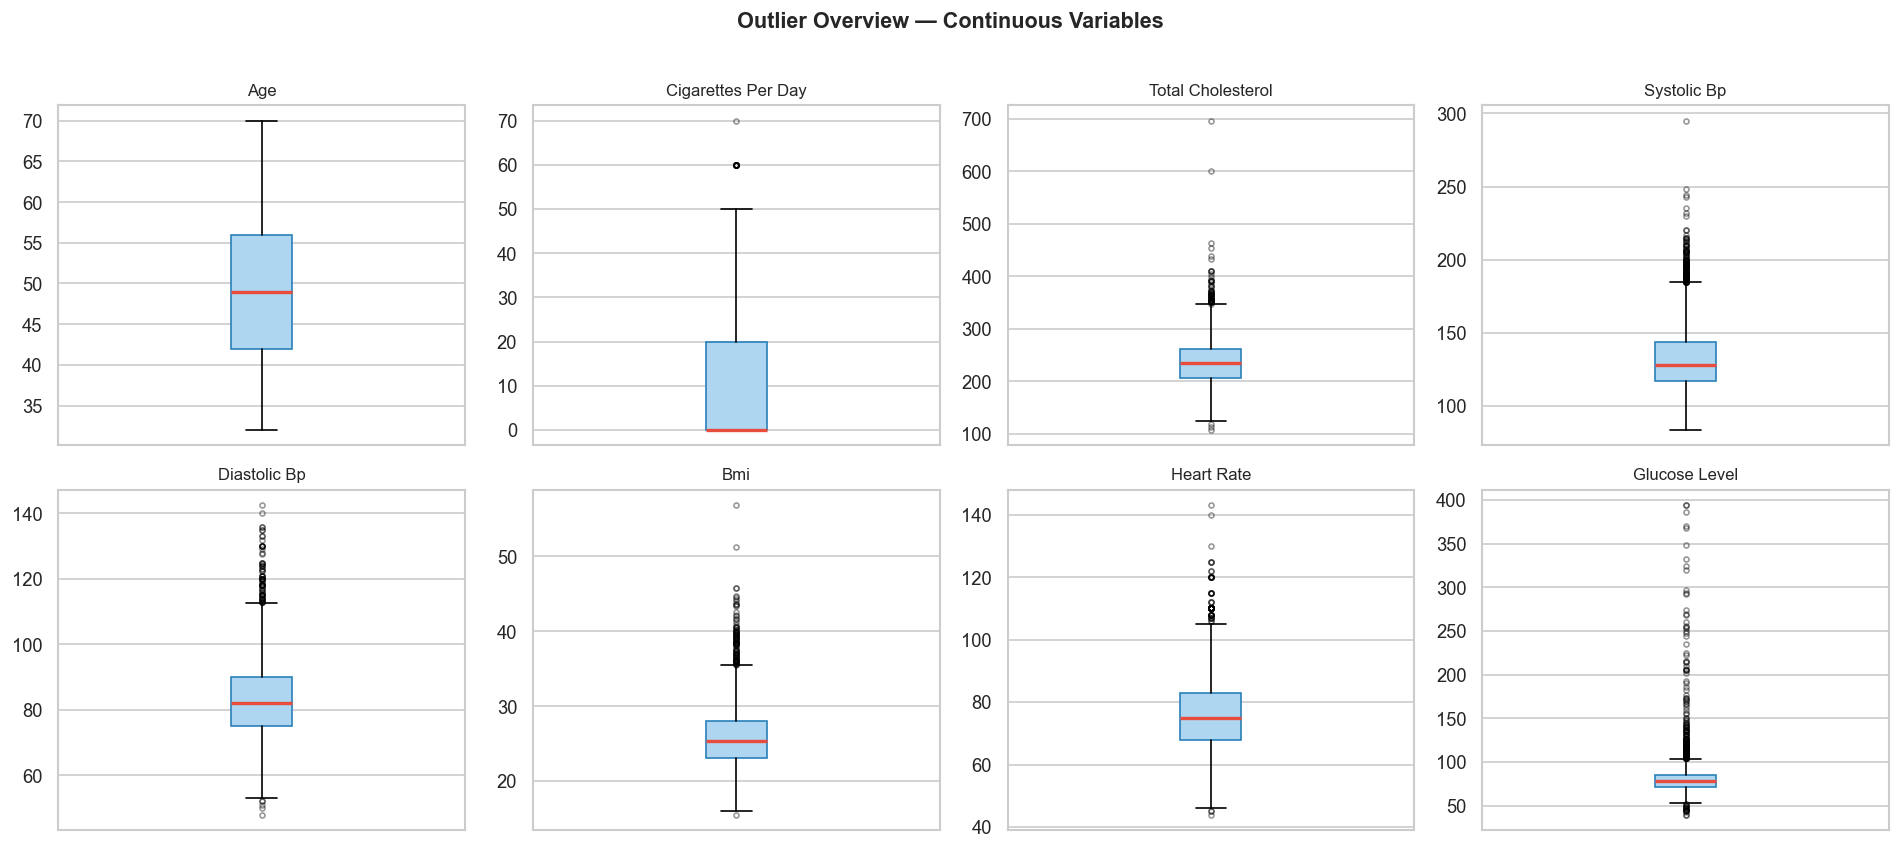

In [22]:
# ── Boxplots for continuous features ─────────────────────────────────────────
CONT_COLS = ['age', 'cigarettes_per_day', 'total_cholesterol',
             'systolic_bp', 'diastolic_bp', 'bmi', 'heart_rate', 'glucose_level']

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

for i, col in enumerate(CONT_COLS):
    axes[i].boxplot(df[col], patch_artist=True,
                    boxprops=dict(facecolor='#AED6F1', color='#2980B9'),
                    medianprops=dict(color='#E74C3C', linewidth=2),
                    flierprops=dict(marker='o', color='#E74C3C', alpha=0.4, markersize=3))
    axes[i].set_title(col.replace('_', ' ').title(), fontsize=10)
    axes[i].set_xticks([])

plt.suptitle('Outlier Overview — Continuous Variables', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()